<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Impute Missing Values**


Estimated time needed: **30** minutes


In this lab, you will practice essential data wrangling techniques using the Stack Overflow survey dataset. The primary focus is on handling missing data and ensuring data quality. You will:

- **Load the Data:** Import the dataset into a DataFrame using the pandas library.

- **Clean the Data:** Identify and remove duplicate entries to maintain data integrity.

- **Handle Missing Values:** Detect missing values, impute them with appropriate strategies, and verify the imputation to create a complete and reliable dataset for analysis.

This lab equips you with the skills to effectively preprocess and clean real-world datasets, a crucial step in any data analysis project.


## Objectives


In this lab, you will perform the following:


-   Identify missing values in the dataset.

-   Apply techniques to impute missing values in the dataset.
  
-   Use suitable techniques to normalize data in the dataset.


-----


#### Install needed library


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 131.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 166.9 MB/s eta 0:00:00


### Step 1: Import Required Libraries


In [3]:
import pandas as pd

### Step 2: Load the Dataset Into a Dataframe


#### **Read Data**
<p>
The functions below will download the dataset into your browser:
</p>


In [4]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### Step 3. Finding and Removing Duplicates
##### Task 1: Identify duplicate rows in the dataset.


In [5]:
#count duplicates
num_duplicates = df.duplicated(                          #duplicated highlights duplicate rows by using true/false
    subset=df.columns.difference(["ResponseId"])         #omits the responsid column
).sum()                                                  #count the duplicated columns (true/false is turned into 1's and 0's

num_duplicates

np.int64(487)

##### Task 2: Remove the duplicate rows from the dataframe.



In [7]:
subset_cols = df.columns.difference(["ResponseId"])                     #omit column ResponseID, it is a unique value for every row"

num_duplicates_before = df.duplicated(subset=subset_cols).sum()         #add up duplicate here

df_dedupe = df.drop_duplicates(subset=subset_cols, keep="first")        #drop_duplicates

num_duplicates_after = df_dedupe.duplicated(subset=subset_cols).sum()   #count after duplicates removes

print ("Before: ", num_duplicates_before)
print ("After: ", num_duplicates_after)

Before:  487
After:  0


### Step 4: Finding Missing Values
##### Task 3: Find the missing values for all columns.


In [8]:
missing_data = df.isnull()  #look for null values
missing_data.head()         #print top 5 rows of data

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,False,False,False,False,False,False,False,False,False,True,...,True,True,True,True,True,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,False,False,True,True
3,False,False,False,False,True,False,True,False,False,False,...,True,True,True,True,True,True,False,False,True,True
4,False,False,False,False,True,False,True,False,False,False,...,True,True,True,True,True,True,False,False,True,True


##### Task 4: Find out how many rows are missing in the column RemoteWork.


In [15]:
df['RemoteWork'].isnull().sum()              #sum adds up all null values of remote work

np.int64(10631)

### Step 5. Imputing Missing Values
##### Task 5: Find the value counts for the column RemoteWork.


In [17]:
value_counts = df['RemoteWork'].value_counts()       #lists count of data in remote work column, reminds me of select distinct in SQL
value_counts

RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
Name: count, dtype: int64

##### Task 6: Identify the most frequent (majority) value in the RemoteWork column.



In [13]:
most_freq_value = df['RemoteWork'].value_counts().idxmax()

most_freq_value

'Hybrid (some remote, some in-person)'

##### Task 7: Impute (replace) all the empty rows in the column RemoteWork with the majority value.



In [18]:
import numpy as np

In [27]:
df['RemoteWork'].replace(np.nan, most_freq_value, inplace=True )   #replace null value with hybrid

/tmp/ipykernel_300/4061697779.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['RemoteWork'].replace(np.nan, most_freq_value, inplace=True )   #replace null value with hybrid


In [28]:
value_counts = df['RemoteWork'].value_counts()       #lists count of data in remote work column, reminds me of select distinct in SQL
value_counts

RemoteWork
Hybrid (some remote, some in-person)    33646
Remote                                  20831
In-person                               10960
Name: count, dtype: int64

##### Task 8: Check for any compensation-related columns and describe their distribution.



In [33]:
!pip install seaborn     #install seaborn for chart

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 149.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 128.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 149.4 MB/s eta 0:00:00


In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
df_salary = df.dropna(subset=['ConvertedCompYearly']) #drop missing rows

In [30]:
df_salary['ConvertedCompYearly'].describe()   #understand numeric data in the column


count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

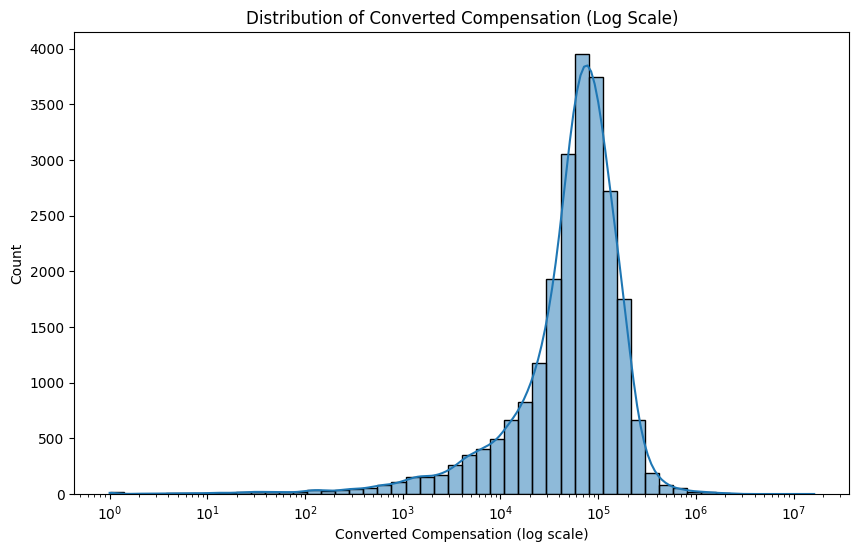

In [36]:
#create histogram

plt.figure(figsize=(10, 6))
sns.histplot(df_salary['ConvertedCompYearly'], bins=50, kde=True, log_scale=True)
plt.title('Distribution of Converted Compensation (Log Scale)')                       #added in log scale to get a clearer picture
plt.xlabel('Converted Compensation (log scale)')
plt.ylabel('Count')
plt.show()


### Summary 


**In this lab, you focused on imputing missing values in the dataset.**

- Use the <code>pandas.read_csv()</code> function to load a dataset from a CSV file into a DataFrame.

- Download the dataset if it's not available online and specify the correct file path.



<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11-05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-09-27|1.1|Madhusudhan Moole|Updated lab|
|2024-09-26|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
